In [ ]:
# to activate this environment, use conda activate rec-genie-env
# to deactivate this environment, use conda deactivate

# following this set up guide https://lkpy.lenskit.org/en/stable/GettingStarted.html

In [10]:
from lenskit.datasets import ML100K
from lenskit import batch, topn, util
from lenskit import crossfold as xf
from lenskit.algorithms import Recommender, als, item_knn as knn
from lenskit import topn


In [11]:
import pandas as pd

In [12]:
%matplotlib inline

In [13]:
ml100k = ML100K('ml-100k')
ratings = ml100k.ratings
ratings.head()

,user,item,rating,timestamp
0,196,242,3.0,881250949
1,186,302,3.0,891717742
2,22,377,1.0,878887116
3,244,51,2.0,880606923
4,166,346,1.0,886397596


In [14]:
algo_ii = knn.ItemItem(20)
algo_als = als.BiasedMF(50)

In [15]:
def eval(aname, algo, train, test):
    fittable = util.clone(algo)
    fittable = Recommender.adapt(fittable)
    fittable.fit(train)
    users = test.user.unique()
    # now we run the recommender
    recs = batch.recommend(fittable, users, 100)
    # add the algorithm name for analyzability
    recs['Algorithm'] = aname
    return recs

In [16]:
all_recs = []
test_data = []
for train, test in xf.partition_users(ratings[['user', 'item', 'rating']], 5, xf.SampleFrac(0.2)):
    test_data.append(test)
    all_recs.append(eval('ItemItem', algo_ii, train, test))
    all_recs.append(eval('ALS', algo_als, train, test))


Numba is using threading layer workqueue - consider TBB
found 1 potential runtime problems - see https://boi.st/lkpy-perf
/Users/Cathal/Rec-Genie/.venv/lib/python3.9/site-packages/lenskit/algorithms/item_knn.py:119: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  b = blocks[bi]


In [17]:
all_recs = pd.concat(all_recs, ignore_index=True)
all_recs.head()

,item,score,user,rank,Algorithm
0,408,4.638010,5,1,ItemItem
1,1594,4.493366,5,2,ItemItem
2,1524,4.447323,5,3,ItemItem
3,114,4.438946,5,4,ItemItem
4,1251,4.436250,5,5,ItemItem


In [18]:
test_data = pd.concat(test_data, ignore_index=True)

In [19]:
rla = topn.RecListAnalysis()
rla.add_metric(topn.ndcg)
results = rla.compute(all_recs, test_data)
results.head()

nrecs      ndcg
Algorithm user                 
ItemItem  5       100  0.180214
          13      100  0.253500
          19      100  0.000000
          25      100  0.284186
          30      100  0.028940

In [20]:
results.groupby('Algorithm').ndcg.mean()

Algorithm
ALS         0.136211
ItemItem    0.098940
Name: ndcg, dtype: float64

<Axes: xlabel='Algorithm'>

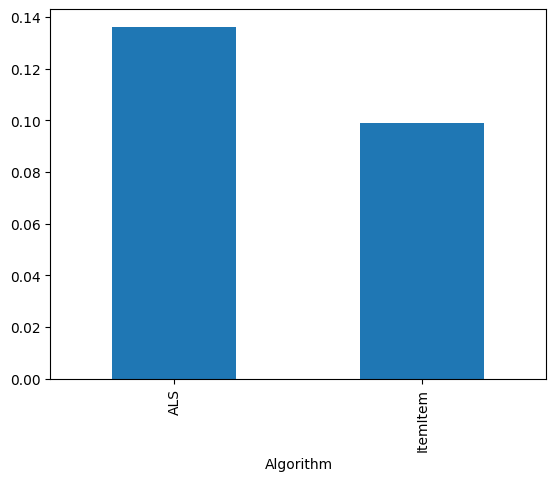

In [21]:
results.groupby('Algorithm').ndcg.mean().plot.bar()